#Libraries

In [2]:
!pip install trimesh -q

In [3]:
import os
import trimesh
import tensorflow as tf
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split

#Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')
Data_Dir = '/content/drive/MyDrive/ModelNet10'
data_categories = os.listdir(Data_Dir)
data_categories

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['chair',
 'night_stand',
 'table',
 'dresser',
 'desk',
 'monitor',
 'bed',
 'bathtub',
 'toilet',
 'sofa']

In [5]:
mesh1 = trimesh.load(os.path.join(Data_Dir, 'chair/train/chair_0001.off'))
mesh1.show()

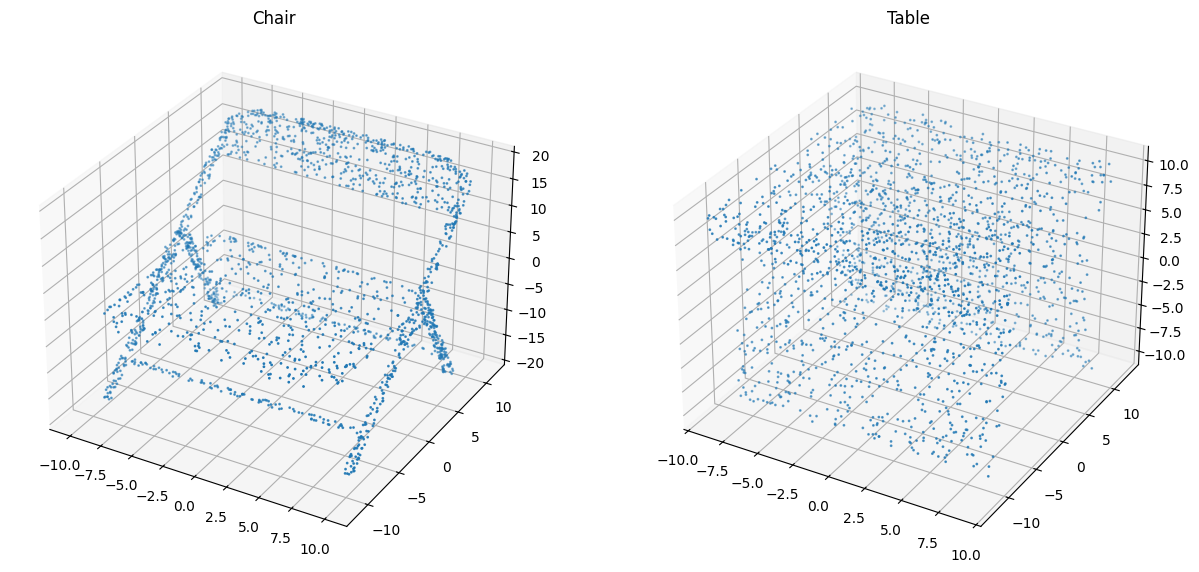

In [6]:
mesh2 = trimesh.load(os.path.join(Data_Dir, 'table/train/table_0002.off'))
points1 = mesh1.sample(2048)
points2 = mesh2.sample(2048)
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')
ax1.scatter(points1[:, 0], points1[:, 1], points1[:, 2], s=1)
ax2.scatter(points2[:, 0], points2[:, 1], points2[:, 2], s=1)
ax1.set_title('Chair')
ax2.set_title('Table')
plt.show()

# Data Preprocessing

In [7]:
def voxelize(mesh, grid_size):
  bounds = mesh.bounds
  bounding_box_size = bounds[1] - bounds[0]
  max_dimension = max(bounding_box_size)
  scale_factor = 1.0 / max_dimension

  # Center the mesh and scale it
  mesh.apply_translation(-mesh.centroid)
  mesh.apply_scale(scale_factor)

  # Voxelize the mesh
  pitch = 1.0/grid_size
  voxel_grid = mesh.voxelized(pitch = pitch)
  matrix = voxel_grid.matrix.astype(np.float32)

  # Creating empty grid
  final_grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)
  min_dimensions = np.minimum(matrix.shape, [grid_size, grid_size, grid_size])

  final_grid[:min_dimensions[0], :min_dimensions[1], :min_dimensions[2]] = \
                         matrix[:min_dimensions[0], :min_dimensions[1], :min_dimensions[2]]

  return final_grid

In [8]:
# Voxelize the train data
base_input_dir = '/content/drive/MyDrive/ModelNet10'

output_dir = '/content/drive/MyDrive/preprocessed_data'

dir_exists = False
if not os.path.exists(output_dir):
    dir_exists = True
    os.makedirs(output_dir)
if len(os.listdir(output_dir)) < 5000 or dir_exists:
  for category in data_categories:
    print(f"\nProcessing group: {category} ")
    category_train_path = os.path.join(base_input_dir, category, 'train')
    category_files = os.listdir(category_train_path)
    for i, filename in enumerate(category_files):
      if i % 50 == 0:
        print(f"Processing file {i+1}/{len(category_files)}: {filename}")
        filename = os.path.join(category_train_path, filename)

        # Create a new filename for the .npy file
        basename = os.path.basename(filename)
        new_filename = os.path.join(output_dir, basename.replace(".off", ".npy"))
        if os.path.exists(new_filename):
          continue

        # Voxelize and save
        mesh = trimesh.load(filename)
        voxels = voxelize(mesh, 64)
        np.save(new_filename, voxels)

else:
     print("The preprocessed data are in the input directory")


Processing group: chair 
Processing file 1/889: chair_0009.off
Processing file 51/889: chair_0025.off
Processing file 101/889: chair_0095.off
Processing file 151/889: chair_0146.off
Processing file 201/889: chair_0211.off
Processing file 251/889: chair_0268.off
Processing file 301/889: chair_0297.off
Processing file 351/889: chair_0359.off
Processing file 401/889: chair_0391.off
Processing file 451/889: chair_0458.off
Processing file 501/889: chair_0522.off
Processing file 551/889: chair_0558.off
Processing file 601/889: chair_0600.off
Processing file 651/889: chair_0641.off
Processing file 701/889: chair_0734.off
Processing file 751/889: chair_0787.off
Processing file 801/889: chair_0805.off
Processing file 851/889: chair_0855.off

Processing group: night_stand 
Processing file 1/200: night_stand_0001.off
Processing file 51/200: night_stand_0117.off
Processing file 101/200: night_stand_0126.off
Processing file 151/200: night_stand_0136.off

Processing group: table 
Processing file 1/

In [9]:
base_input_dir = '/content/drive/MyDrive/ModelNet10'
output_dir = '/content/drive/MyDrive/voxelized_test_data'

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")

# Check if the directory is empty. If so, process the test data.
if not os.listdir(output_dir):
    print(f"Voxelizing test data into: {output_dir}")
    for category in data_categories:
      print(f"\nProcessing group: {category} ")
      category_test_path = os.path.join(base_input_dir, category, 'test')
      category_files = os.listdir(category_test_path)
      for i, filename in enumerate(category_files):
        if i % 25 == 0: # Print progress less frequently for test data
          print(f"Processing file {i+1}/{len(category_files)}: {filename}")

        full_filename_path = os.path.join(category_test_path, filename)

        # Create a new filename for the .npy file
        basename = os.path.basename(filename)
        new_filename = os.path.join(output_dir, basename.replace(".off", ".npy"))

        # Only process if the file doesn't already exist
        if not os.path.exists(new_filename):
            # Voxelize and save
            mesh = trimesh.load(full_filename_path)
            voxels = voxelize(mesh, 64)
            np.save(new_filename, voxels)
    print("Finished voxelizing test data.")
else:
    print(f"Test data already present in {output_dir}. Skipping voxelization.")

The test data are in the input directory


# Define the dataset

In [10]:
class VoxelizedDataset(tf.keras.utils.Sequence):
  def __init__(self, filenames, batch_size, augment = False, max_translation = 5, **kwargs):
    super().__init__(**kwargs)
    self.filenames = filenames
    self.batch_size = batch_size
    self.augment = augment
    self.max_translation = max_translation

  def __len__(self):
    return int(np.floor(len(self.filenames) / self.batch_size))

  def apply_augmentations(self, voxel_grid):
    shifts = np.random.randint(-self.max_translation, self.max_translation + 1, size =3)
    augmented_grid = np.roll(voxel_grid, shifts, axis = (0, 1, 2))
    if np.random.rand() > 0.5:
      augmented_grid = np.flip(augmented_grid, axis = 2)
    return augmented_grid

  def __getitem__(self, index):
    batch_filenames = self.filenames[index * self.batch_size : (index + 1) * self.batch_size]
    original_batch = np.array([np.load(f) for f in batch_filenames])
    if self.augment:
      augmented_batch = np.array([self.apply_augmentations(grid) for grid in original_batch])
      current_batch = np.concatenate([original_batch, augmented_batch], axis = 0)
      target_batch = np.concatenate([original_batch, original_batch], axis = 0)
    else:
      current_batch = original_batch
      target_batch = original_batch

    modified_batch = np.where(target_batch == 1, 2.0, -1.0)
    current_batch = np.expand_dims(current_batch, axis = -1)
    modified_batch = np.expand_dims(modified_batch, axis = -1)
    return current_batch, modified_batch

#Functions

In [11]:
class Sampling(layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape = (batch, dim))
    return z_mean + tf.exp(0.5*z_log_var) * epsilon

In [12]:
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2

L2_WEIGHT = 1e-5
GAMMA = 0.97
def weighted_bce_loss(y_true, y_pred, gamma):
  y_pred = tf.cast(y_pred, tf.float32)
  y_true = tf.cast(y_true, tf.float32)
  y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())

  loss = -gamma * y_true * K.log(y_pred) - (1 - gamma) * (1 - y_true) * K.log(1 - y_pred)
  return loss

#VAE model

In [13]:
def build_encoder(input_dim, latent_dim, l2_weight):
  encoder_inputs = layers.Input(shape = input_dim)
  x = layers.Conv3D(32, 3, activation = 'elu', strides = 2, padding ='same', kernel_regularizer=l2(l2_weight))(encoder_inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Conv3D(64, 3, activation = 'elu', strides = 2, padding = 'same', kernel_regularizer=l2(l2_weight))(x)
  x = layers.BatchNormalization()(x)

  # Residual Block
  residual = x
  x = layers.Conv3D(128, 3, activation='elu', strides = 2, padding = 'same', kernel_regularizer=l2(l2_weight))(x)
  x = layers.BatchNormalization()(x)
  x = layers.Conv3D(128, 3, activation = 'elu', padding = 'same', kernel_regularizer=l2(l2_weight))(x)
  x = layers.BatchNormalization()(x)

  # ResNet architecture
  residual_downsampled = layers.Conv3D(128, 1, strides = 2, padding ='same')(residual)
  x = layers.add([x, residual_downsampled])

  # Flaten and map to the latent space
  x = layers.Flatten()(x)
  x = layers.Dense(256, activation = 'elu')(x)

  # Mean and Log Variance
  z_mean = layers.Dense(latent_dim, name = 'z_mean', kernel_regularizer = l2(l2_weight))(x)
  z_log_var = layers.Dense(latent_dim, name = 'z_log_var', kernel_regularizer = l2(l2_weight))(x)
  z = Sampling()([z_mean, z_log_var])
  encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name = 'encoder')
  return encoder

In [14]:
def scaled_sigmoid_activation(x):
    sigmoid = tf.math.sigmoid(x)
    return (sigmoid * 0.9) + 0.1

def build_decoder(latent_dim, reshape_dims, l2_weight):
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(256, activation='elu')(latent_inputs)

    # Upsampling the latent vector
    x = layers.Dense(reshape_dims[0] * reshape_dims[1] * reshape_dims[2] * 128, activation="elu")(x)
    x = layers.Reshape(reshape_dims)(x)


     # Residual block
    residual = x
    x = layers.Conv3DTranspose(128, 3, activation='elu', padding='same', kernel_regularizer=l2(l2_weight))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3DTranspose(128, 3, activation='elu', strides=2, padding='same', kernel_regularizer=l2(l2_weight))(x)
    x = layers.BatchNormalization()(x)

    # Connection
    residual = layers.Conv3DTranspose(128, 1, strides=2, padding='same')(residual)
    x = layers.add([x, residual])
    x = layers.Activation('elu')(x)
    x = layers.Conv3DTranspose(64, 3, activation = 'elu', strides = 2, padding = 'same', kernel_regularizer = l2(l2_weight))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3DTranspose(32, 3, activation = 'elu', strides = 2, padding = 'same', kernel_regularizer = l2(l2_weight))(x)
    x = layers.BatchNormalization()(x)

    # Reconstructing the voxel grid
    decoder_outputs = layers.Conv3DTranspose(1, 3, activation = scaled_sigmoid_activation, padding="same", kernel_regularizer = l2(l2_weight))(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name = 'decoder')
    return decoder

In [15]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name = 'total_loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name = 'reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name = 'kl_loss')

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            x, targets = data
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    weighted_bce_loss(targets, reconstruction, gamma = GAMMA),
                    axis=(1, 2,3),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss + (tf.add_n(self.losses) if self.losses else 0)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x, targets = data

        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(weighted_bce_loss(targets, reconstruction, gamma = GAMMA), axis=(1, 2, 3)))
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

        total_loss = reconstruction_loss + self.beta * kl_loss + (tf.add_n(self.losses) if self.losses else 0)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

In [16]:
latent_dim = 128
input_dim = (64,64,64,1)
reshape_dim = (8,8,8,128)
encoder = build_encoder(input_dim, latent_dim, L2_WEIGHT)
decoder = build_decoder(latent_dim, reshape_dim, L2_WEIGHT)
vae = VAE(encoder,decoder, beta = 10)

encoder.summary()
print("\n\n")
decoder.summary()
print("\n")
vae.build(input_shape=(None, 64, 64, 64, 1))

vae.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 16, 16,    │     55,360 │ batch_normalizat… │
│                     │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 8, 8,   │    221,312 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 8,   │        512 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 8, 8, 8,   │    442,496 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 8,   │        512 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 8, 8, 8,   │      8,320 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 8,   │          0 │ batch_normalizat… │
│                     │ 128)              │            │ conv3d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 65536)     │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 16,777,472 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,573,056 (67.04 MB)

 Trainable params: 17,572,352 (67.03 MB)

 Non-trainable params: 704 (2.75 KB)

...

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 128), (None,   │    17,573,056 │
│                                 │ 128), (None, 128))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 64, 1)  │    18,056,129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,629,185 (135.91 MB)

 Trainable params: 35,627,777 (135.91 MB)

 Non-trainable params: 1,408 (5.50 KB)

# Train the model

In [17]:
preprocessed_dir = '/content/drive/MyDrive/preprocessed_data'
all_processed_files = os.listdir(preprocessed_dir)

categories = [f.split('_')[0] for f in all_processed_files]

train_processed, val_processed = train_test_split(
    all_processed_files,
    test_size=0.2,
    random_state=42,
    stratify = categories
)
train_full_paths = [os.path.join(preprocessed_dir, f) for f in train_processed]
val_full_paths = [os.path.join(preprocessed_dir, f) for f in val_processed]
print(len(val_full_paths))

798


In [18]:
class PrintLR(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        optimizer = self.model.optimizer
        current_lr = optimizer.learning_rate

        if isinstance(current_lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            step = optimizer.iterations
            lr = current_lr(step)
            print(f" - LR: {lr.numpy():.7f}")
        else:
            print(f" - LR: {current_lr:.7f}")

In [19]:
import tensorflow as tf
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate, warmup_steps, decay_steps, alpha=0.0):
        super(WarmupCosineDecay, self).__init__()
        self.initial_learning_rate = initial_learning_rate
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        self.alpha = alpha

        self.cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_learning_rate,
            decay_steps=decay_steps,
            alpha=alpha
        )

    def __call__(self, step):
        with tf.name_scope("WarmupCosineDecay"):
            initial_learning_rate = tf.convert_to_tensor(self.initial_learning_rate, name="initial_learning_rate")

            return tf.cond(
                step < self.warmup_steps,
                # Warmup Phase: Linear increase
                lambda: (initial_learning_rate / self.warmup_steps) * step,
                # Decay Phase: Cosine decay
                lambda: self.cosine_decay(step - self.warmup_steps)
            )

    def get_config(self):
        return {
            "initial_learning_rate": self.initial_learning_rate,
            "warmup_steps": self.warmup_steps,
            "decay_steps": self.decay_steps,
            "alpha": self.alpha,
        }

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
BATCH_SIZE = 32
NUM_EPOCHS = 100
NUM_WORKERS = os.cpu_count() - 1
WARMUP_EPOCHS = 10
train_generator = VoxelizedDataset(train_full_paths, batch_size=BATCH_SIZE, augment = True)
val_generator = VoxelizedDataset(val_full_paths, batch_size=BATCH_SIZE, augment = False)
print(len(val_generator))

steps_per_epoch = len(train_generator)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch
decay_steps = total_steps - warmup_steps

lr_schedule = WarmupCosineDecay(
    initial_learning_rate=0.01,
    warmup_steps=warmup_steps,
    decay_steps=decay_steps,
    alpha=0.01
)

model_checkpoint_callback = ModelCheckpoint(
    filepath='best_vae_model.weights.h5',
    save_weights_only=True,
    monitor='val_total_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_total_loss',
    patience=10,
    mode='min',
    verbose=1,
    restore_best_weights=True
)
optimizer = tf.keras.optimizers.SGD(learning_rate = lr_schedule, momentum = 0.9, nesterov = True, clipnorm = 1.0)
print_lr_callback = PrintLR()

24


In [21]:
# Training
print("Starting the training process")
vae.compile(optimizer = optimizer)
history = vae.fit(
    train_generator,
    epochs = NUM_EPOCHS,
    validation_data = val_generator,
    callbacks = [model_checkpoint_callback, early_stopping_callback, print_lr_callback]
)

Starting the training process
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - kl_loss: 2.3738 - loss: -146976.1693 - reconstruction_loss: -146999.8931
Epoch 1: val_total_loss improved from None to -496794.53125, saving model to best_vae_model.weights.h5

Epoch 1: finished saving model to best_vae_model.weights.h5
 - LR: 0.0010000
99/99 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - kl_loss: 16.6630 - loss: -226857.7344 - reconstruction_loss: -227024.3281 - val_kl_loss: 39.9620 - val_reconstruction_loss: -497194.1562 - val_total_loss: -496794.5312
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - kl_loss: 7.3280 - loss: -506559.6086 - reconstruction_loss: -506632.9129
Epoch 2: val_total_loss improved from -496794.53125 to -509576.46875, saving model to best_vae_model.weights.h5

Epoch 2: finished saving model to best_vae_model.weights.h5
 - LR: 0.0020000
99/99 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - kl_loss: 2.0126 - loss: -508578.3125 - reconstruction_loss: -508598.4688 - val_kl_loss: 0.0103 - 

# Model testing

In [22]:
def calculate_reconstruction_similarity(originals, reconstructions, threshold=0.5):

    # Binarize the voxel grids
    original_binary = tf.cast(originals > threshold, dtype=tf.float32)
    reconstructed_binary = tf.cast(reconstructions > threshold, dtype=tf.float32)
    original_flat = tf.reshape(original_binary, [original_binary.shape[0], -1])
    reconstructed_flat = tf.reshape(reconstructed_binary, [reconstructed_binary.shape[0], -1])

    # Calculate the intersection and union
    intersection = tf.reduce_sum(original_flat * reconstructed_flat, axis=1)
    union = tf.reduce_sum(original_flat, axis=1) + tf.reduce_sum(reconstructed_flat, axis=1) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)

    return tf.reduce_mean(iou) * 100

In [23]:
recreated_vae = VAE(encoder=encoder, decoder=decoder, beta = 10)

recreated_vae.build(input_shape=(None, 64, 64, 64, 1))

model_trained_now_file = 'best_vae_model.weights.h5'
model_trained_previously = 'previous-best-weights/best_vae_model.weights.h5'
if os.path.exists(model_trained_now_file):
    recreated_vae.load_weights(model_trained_now_file)
    print("VAE weights from trained model loaded successfully!")
else:
    recreated_vae.load_weights(model_trained_previously)
    print("VAE weights loaded successfully!")

recreated_vae.compile(optimizer = optimizer)

VAE weights from trained model loaded successfully!


In [41]:
test_full_path = '/content/drive/MyDrive/voxelized_test_data'
# Filter all_test_files to include only actual files with .npy extension
all_test_files = [f for f in os.listdir(test_full_path) if os.path.isfile(os.path.join(test_full_path, f)) and f.endswith('.npy')]
full_file_paths = [os.path.join(test_full_path, f) for f in all_test_files]

test_generator = VoxelizedDataset(full_file_paths, batch_size = 32, augment = False)
print(f"Test generator created with {len(test_generator)} batches.")

# Check if there's any data in the generator before proceeding
if len(test_generator) > 0:
    print("\nEvaluating model performance on the test dataset...")
    test_metrics = recreated_vae.evaluate(test_generator, verbose=1)
    print("\nTest Results: ")
    print(f"Test Total Loss: {test_metrics[0]:.4f}")
    if len(test_metrics) > 1:
        print(f"Test Reconstruction Loss: {test_metrics[1]:.4f}")
        print(f"Test KL Loss: {test_metrics[2]:.4f}")

    original_voxels, _ = next(iter(test_generator))

    # Use the model to reconstruct the voxels
    reconstructed_voxels = recreated_vae.predict(original_voxels)

    # Calculate the similarity for the batch
    avg_iou = calculate_reconstruction_similarity(original_voxels, reconstructed_voxels)

    print(f"Average IoU: {avg_iou}%")
else:
    print("No valid test data (.npy files) found in the test directory. Please ensure the test data has been voxelized correctly by running cell Oi-4dn8GUVpS after clearing any non-.npy files or directories from '/content/drive/MyDrive/voxelized_test_data'.")

Test generator created with 124 batches.

Evaluating model performance on the test dataset...
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 303ms/step - kl_loss: 0.0038 - reconstruction_loss: -509111.9688 - total_loss: -509111.9062

Test Results: 
Test Total Loss: -509111.9062
Test Reconstruction Loss: -509111.9688
Test KL Loss: 0.0038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
Average IoU: 1.2125683568342538e-08%


In [42]:
def plot_voxels(voxel_grid, title="", threshold = 0.6):
    voxel_grid = np.squeeze(voxel_grid)

    # Use a threshold to convert the model's probabilistic output (0.0 to 1.0)
    # into a definite binary grid for clear plotting.
    binary_grid = voxel_grid > threshold

    # Create a 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    # Use the ax.voxels() function to draw the grid
    ax.voxels(binary_grid, edgecolor='k')

    ax.set_title(title)
    plt.show()

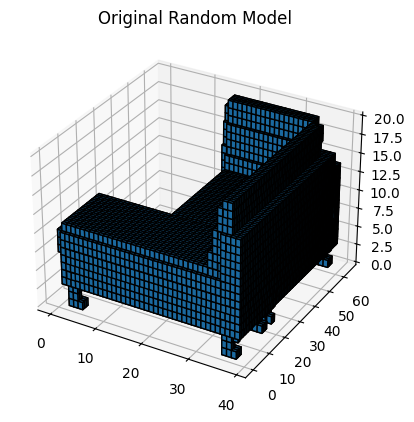

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


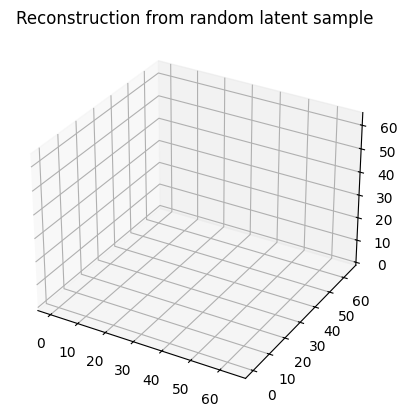

In [43]:
# Adding Batch dim
random_model = np.expand_dims(np.load(full_file_paths[25]), axis=0)
random_model = np.expand_dims(random_model, axis=-1)
plot_voxels(np.squeeze(random_model), title="Original Random Model")
z_random = recreated_vae.encoder.predict(random_model)[0]

#plot_voxels(np.squeeze(z_random_mean), title="Mean of random object")
#plot_voxels(np.squeeze(z_random), title = "Sample of random object")

reconstructed_voxel_grid = recreated_vae.decoder.predict(z_random)
plot_voxels(np.squeeze(reconstructed_voxel_grid), title="Reconstruction from random latent sample", threshold = 0.9)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


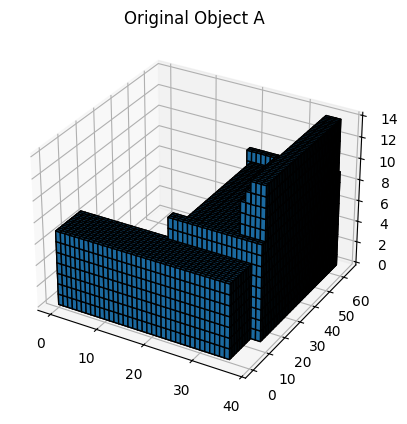

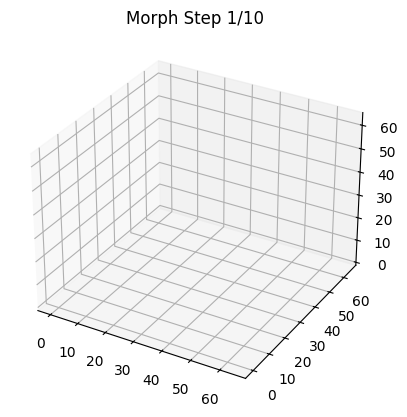

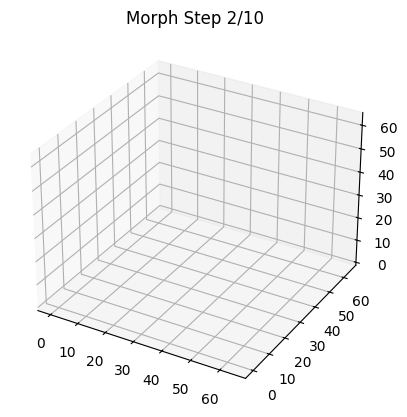

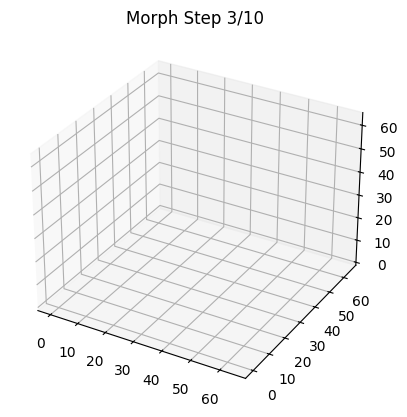

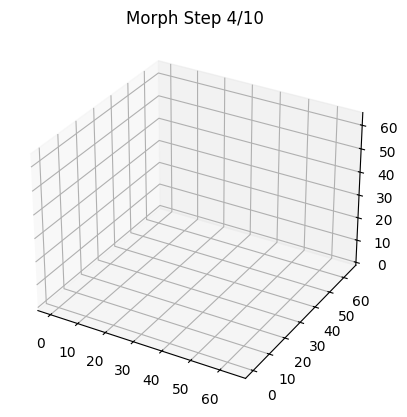

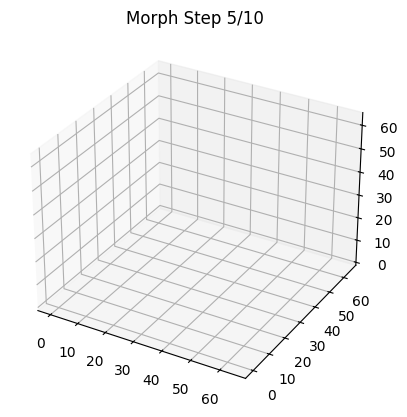

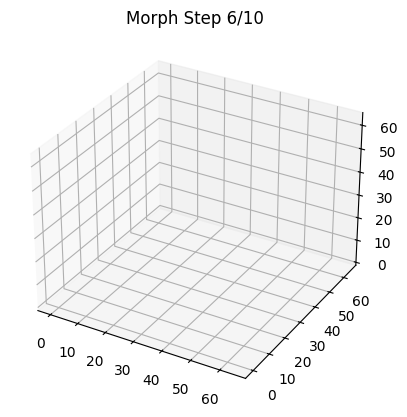

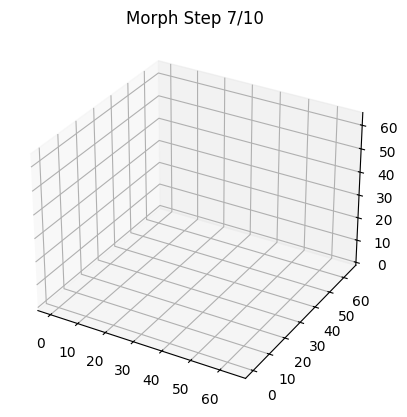

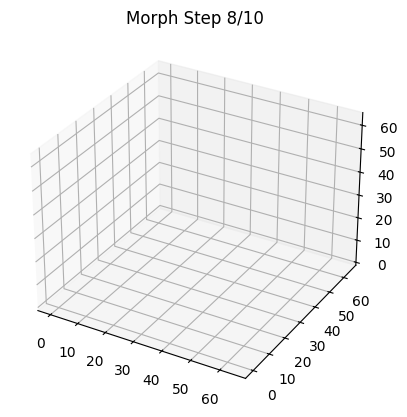

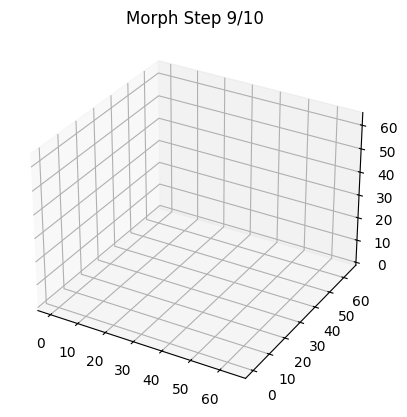

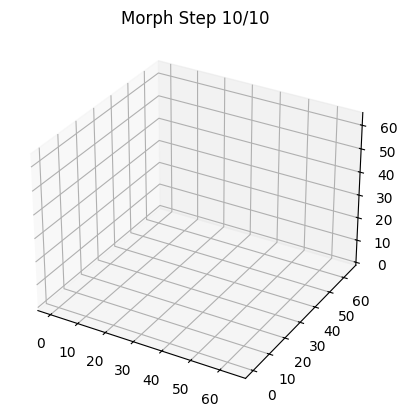

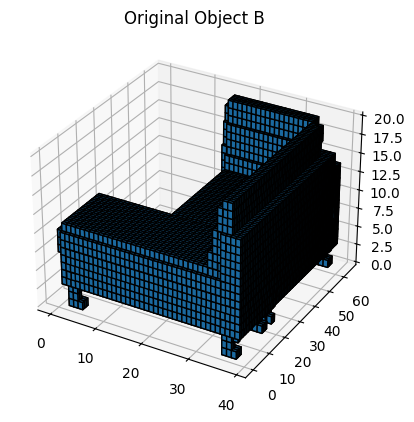

In [44]:
model_a = np.expand_dims(np.load(full_file_paths[5]), axis=0) # Add batch dim
model_a = np.expand_dims(model_a, axis=-1) # Add channel dim

model_b = np.expand_dims(np.load(full_file_paths[25]), axis=0)
model_b = np.expand_dims(model_b, axis=-1)

# The encoder output is [z_mean, z_log_var, z].
z_a = recreated_vae.encoder.predict(model_a)[0]
z_b = recreated_vae.encoder.predict(model_b)[0]

num_steps = 10
interpolated_vectors = np.array([z_a + (z_b - z_a) * t for t in np.linspace(0, 1, num_steps)])
interpolated_vectors = np.squeeze(interpolated_vectors, axis=1) # Remove extra dimension

morphed_voxels = recreated_vae.decoder.predict(interpolated_vectors)


plot_voxels(np.squeeze(model_a), title="Original Object A")

# This loop shows the steps between the originals
for i in range(num_steps):
    plot_voxels(morphed_voxels[i], title=f"Morph Step {i+1}/{num_steps}", threshold = 0.75)

plot_voxels(np.squeeze(model_b), title="Original Object B")